In [ ]:
import numpy as np
import matplotlib.pyplot as plt

The first section only shows the constants. All of these numbers can be changed, but it is not adviced. The initial conditions are kind of whiny and break down when conditions are not exact. Grid size can be changed, but changing the domain and the viscosity has a tendency to destroy the graph.

In [ ]:
##Constants

Nx = 50  ##Grid size
L = 1  ##Domain
dx = L / (Nx - 1)
x = np.linspace(0, L, Nx)

T = 2  ##final time
Nt = 1000  ##Timesteps, feel free to change, but keep large
dt = T / Nt  ##Number of steps
nu = 0.01  ##Viscosity
np.random.seed(42)

This section defines the random setup and sets the boundaries.

In [ ]:
u = np.sin(np.pi * x) + 0.1 * np.random.rand(Nx)

def period(arr):
  """The boundary conditions :3"""

  arr[0] = arr[-2]
  arr[-1] = arr[1]
  return arr

def upwind(phi, dx):
  """Compute upwind for Burger"""

  phi_x = np.zeros_like(phi)
  ##Positive velocity
  phi_x[1:-1] = np.where(phi[1: -1] > 0,
                         (phi[1: -1] - phi[0: -2]) / dx,
                         (phi[2:] - phi[1: -1]) / dx
                         )
  return phi_x

def laplace(phi, dx):
  return (phi[2:] - 2 * phi[1: -1] + phi[0: -2]) / dx**2

This is the derivative and laplacian for the next portion.

In [ ]:
for n in range(Nt):
  u = period(u)

  u_x = upwind(u, dx)
  u_xx = laplace(u, dx)

  u[1: -1] += dt * (-u[1: -1] * u_x[1: -1] + nu * u_xx)

Graph

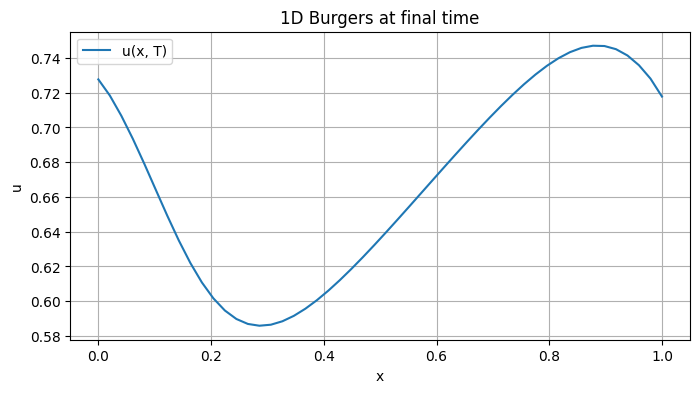

In [ ]:
plt.figure(figsize = (8, 4))
plt.plot(x, u, label = 'u(x, T)')
plt.title('1D Burgers at final time')
plt.xlabel('x')
plt.ylabel('u')
plt.grid(True)
plt.legend()
plt.show()